In [3]:
from keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
print('Shape of x_train: ' + str(x_train.shape))
print('Shape of x_test: '+ str(x_test.shape))
print('Shape of y_train: '+ str(y_train.shape))
print('Shape of y_test: '+ str(y_test.shape))

Shape of x_train: (60000, 28, 28)
Shape of x_test: (10000, 28, 28)
Shape of y_train: (60000,)
Shape of y_test: (10000,)


In [6]:
x_train_vec = x_train.reshape((60000, 28, 28, 1)) / 255
x_test_vec = x_test.reshape((10000, 28, 28, 1)) / 255
print("Shape of x_train_vec is" + str(x_train_vec.shape))

Shape of x_train_vec is(60000, 28, 28, 1)


In [9]:
#One-hot encode: convert the labels (scalars in	0, 1, ⋯ , 9	) to 10-dim  vectors.
import numpy as np
def to_one_hot(labels, dimension=10):
    results = np.zeros((len(labels), dimension))
    for i, label in enumerate(labels):
        results[i, label] = 1.
    return results

y_train_vec = to_one_hot(y_train)
y_test_vec = to_one_hot(y_test)
print('Shape of y_train_vec is ' + str(y_train_vec.shape))


Shape of y_train_vec is (60000, 10)


In [10]:
# Partition to training and validation sets

rand_indices = np.random.permutation(60000)
train_indices = rand_indices[0:50000]
valid_indices = rand_indices[50000:60000]

x_valid_vec = x_train_vec[valid_indices, :, :, :]
y_valid_vec = y_train_vec[valid_indices, :]

x_train_vec = x_train_vec[train_indices, :, :, :]
y_train_vec = y_train_vec[train_indices, :]



In [11]:
print("Shape of x_valid_vec:" + str(x_valid_vec.shape))
print("Shape of y_valid_vec:" + str(y_valid_vec.shape))
print("Shape of x_train_vec:" + str(x_train_vec.shape))
print("Shape of y_train_vec:" + str(y_train_vec.shape))

Shape of x_valid_vec:(10000, 28, 28, 1)
Shape of y_valid_vec:(10000, 10)
Shape of x_train_vec:(50000, 28, 28, 1)
Shape of y_train_vec:(50000, 10)


In [13]:
from keras import layers
from keras import models
model = models.Sequential()
model.add(layers.Conv2D(10, (5, 5), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(20, (5, 5), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(100, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))
model.summary()
model

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)                    │ (None, 24, 24, 10)          │             260 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 12, 12, 10)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 20)            │           5,020 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 4, 4, 20)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 320)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 100)                 │          32,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 38,390 (149.96 KB)

 Trainable params: 38,390 (149.96 KB)

 Non-trainable params: 0 (0.00 B)

<Sequential name=sequential_1, built=True>

In [15]:
from keras import optimizers
model.compile(optimizers.RMSprop(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [16]:
history = model.fit(x_train_vec, y_train_vec,
                    batch_size=128, epochs=50,
                    validation_data=(x_valid_vec, y_valid_vec))


Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 67ms/step - accuracy: 0.4691 - loss: 1.8769 - val_accuracy: 0.8473 - val_loss: 0.5640
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 66ms/step - accuracy: 0.8741 - loss: 0.4584 - val_accuracy: 0.9068 - val_loss: 0.3117
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 65ms/step - accuracy: 0.9148 - loss: 0.2924 - val_accuracy: 0.9279 - val_loss: 0.2383
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.9341 - loss: 0.2244 - val_accuracy: 0.9437 - val_loss: 0.1900
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 42s 65ms/step - accuracy: 0.9446 - loss: 0.1884 - val_accuracy: 0.9504 - val_loss: 0.1610
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.9542 - loss: 0.1562 - val_accuracy: 0.9574 - val_loss: 0.1413
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 51s 92ms/step - accuracy: 0.9617 - loss: 0.1324 - val_accuracy: 0.9645 - val_loss: 0.1217
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 67ms/step - accuracy: 0.9667 - loss: 0.1146 - 

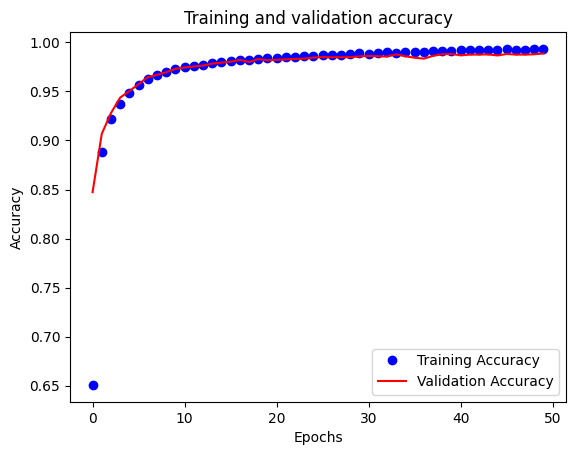

In [19]:
import matplotlib.pyplot as plt
%matplotlib inline

epochs = range(50) #50 is the number of epochs
train_acc = history.history['accuracy']
valid_acc = history.history['val_accuracy']
plt.plot(epochs, train_acc, 'bo', label='Training Accuracy')
plt.plot(epochs, valid_acc, 'r', label='Validation Accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [20]:
loss_and_acc = model.evaluate(x_test_vec, y_test_vec)
print('loss = ' + str(loss_and_acc[0]))
print('accuracy = ' + str(loss_and_acc[1]))


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9846 - loss: 0.0417
loss = 0.03478709235787392
accuracy = 0.9876999855041504
